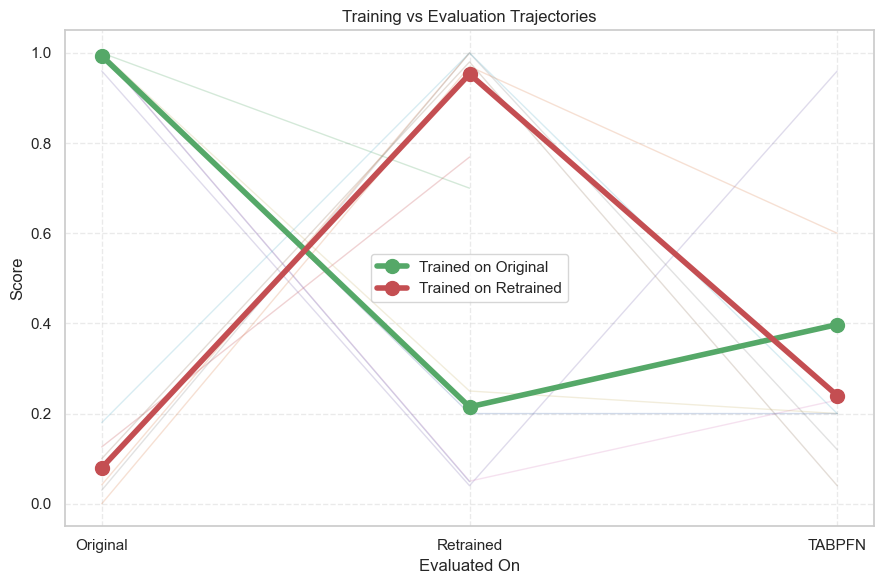

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
df = pd.read_excel("../data/numbers-from-submissions.xlsx")

# Convert to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# --- COLUMN GROUPS ---
original_cols = [
    "Original-original",
    "original-retrained",
    "original-tabpfn"
]

retrained_cols = [
    "retrained-original",
    "retrained-retrained",
    "retrained-tabfpn"
]

x_labels = ["Original", "Retrained", "TABPFN"]
x = np.arange(3)

plt.figure(figsize=(9, 6))

# --- PLOT INDIVIDUAL TRAJECTORIES ---
for _, row in df.iterrows():

    orig_vals = row[original_cols].values.astype(float)
    retr_vals = row[retrained_cols].values.astype(float)

    # thin transparent lines
    plt.plot(
        x,
        orig_vals,
        alpha=0.25,
        linewidth=1
    )

    plt.plot(
        x,
        retr_vals,
        alpha=0.25,
        linewidth=1
    )

# --- PLOT AVERAGES (THICK) ---
orig_mean = df[original_cols].mean().values
retr_mean = df[retrained_cols].mean().values

plt.plot(
    x,
    orig_mean,
    marker="o",
    linewidth=4,
    markersize=10,
    label="Trained on Original"
)

plt.plot(
    x,
    retr_mean,
    marker="o",
    linewidth=4,
    markersize=10,
    label="Trained on Retrained"
)

# Formatting
plt.xticks(x, x_labels)
plt.xlabel("Evaluated On")
plt.ylabel("Score")
plt.title("Training vs Evaluation Trajectories")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()

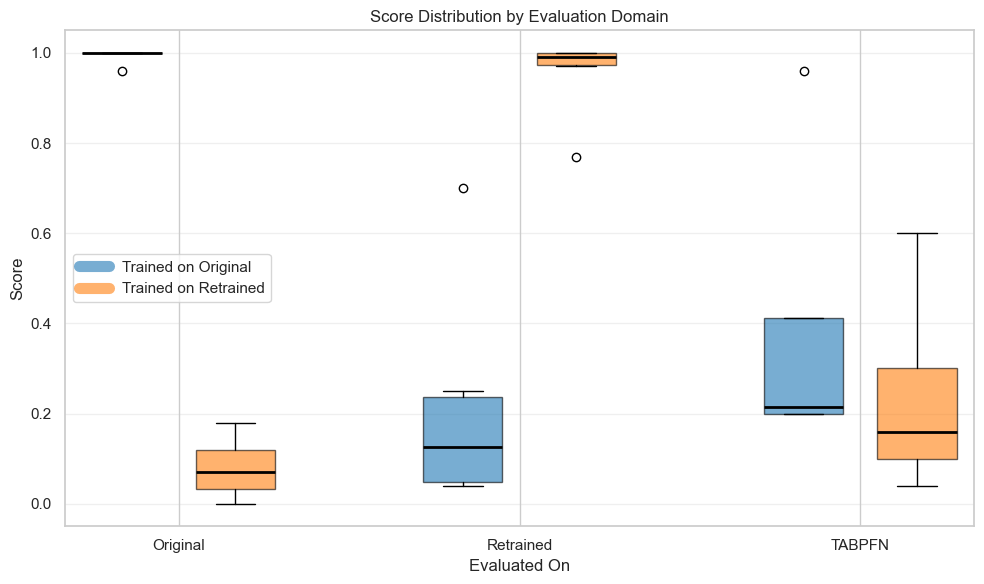

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
# Read Excel file
df = pd.read_excel("../data/numbers-from-submissions.xlsx")

# Convert numeric
df = df.apply(pd.to_numeric, errors="coerce")

# --- COLUMN GROUPS ---
original_cols = [
    "Original-original",
    "original-retrained",
    "original-tabpfn"
]

retrained_cols = [
    "retrained-original",
    "retrained-retrained",
    "retrained-tabfpn"
]



eval_labels = ["Original", "Retrained", "TABPFN"]

# Colors
orig_color = "#1f77b4"
retr_color = "#ff7f0e"

# Prepare grouped boxplot data
data = []
positions = []
colors = []

for i in range(3):

    # trained on original
    data.append(df[original_cols[i]].dropna())
    positions.append(i * 3 + 1)
    colors.append(orig_color)

    # trained on retrained
    data.append(df[retrained_cols[i]].dropna())
    positions.append(i * 3 + 2)
    colors.append(retr_color)

# Plot
plt.figure(figsize=(10, 6))

bp = plt.boxplot(
    data,
    positions=positions,
    widths=0.7,
    patch_artist=True
)

# Consistent coloring
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

# Optional styling
for median in bp['medians']:
    median.set_color("black")
    median.set_linewidth(2)

# X-axis labels centered between each pair
xtick_positions = [1.5, 4.5, 7.5]

plt.xticks(
    xtick_positions,
    eval_labels
)

# Manual legend
plt.plot([], [], color=orig_color, linewidth=8,
         alpha=0.6, label="Trained on Original")

plt.plot([], [], color=retr_color, linewidth=8,
         alpha=0.6, label="Trained on Retrained")

plt.ylabel("Score")
plt.xlabel("Evaluated On")
plt.title("Score Distribution by Evaluation Domain")

plt.grid(True, axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

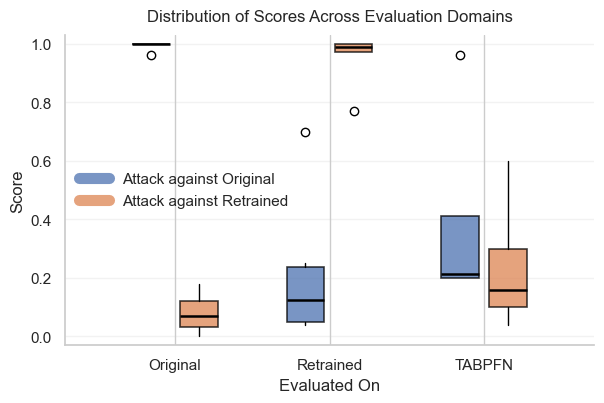

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read Excel file
# Read Excel file
df = pd.read_excel("../data/numbers-from-submissions.xlsx")

# Convert numeric
df = df.apply(pd.to_numeric, errors="coerce")

# --- COLUMN GROUPS ---
original_cols = [
    "Original-original",
    "original-retrained",
    "original-tabpfn"
]

retrained_cols = [
    "retrained-original",
    "retrained-retrained",
    "retrained-tabfpn"
]


eval_labels = ["Original", "Retrained", "TABPFN"]

# Colors
orig_color = "#4C72B0"
retr_color = "#DD8452"

# ---- PREPARE DATA ----
data = []
positions = []
colors = []

group_centers = []
spacing_within = 0.28   # distance inside pair
spacing_between = 0.9   # distance between groups

for i in range(3):

    center = i * spacing_between
    group_centers.append(center)

    # original-trained
    positions.append(center - spacing_within/2)
    data.append(df[original_cols[i]].dropna())
    colors.append(orig_color)

    # retrained-trained
    positions.append(center + spacing_within/2)
    data.append(df[retrained_cols[i]].dropna())
    colors.append(retr_color)

# ---- PLOT ----
fig, ax = plt.subplots(figsize=(6.2, 4.2))

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.22,
    patch_artist=True,
    showcaps=False
)

# Style boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_linewidth(1.2)

# Style medians
for median in bp['medians']:
    median.set_color("black")
    median.set_linewidth(1.8)

# Optional: subtle whiskers
for whisker in bp['whiskers']:
    whisker.set_linewidth(1)

# ---- AXES ----
ax.set_xticks(group_centers)
ax.set_xticklabels(eval_labels)

ax.set_ylabel("Score")
ax.set_xlabel("Evaluated On")

ax.set_title("Distribution of Scores Across Evaluation Domains", pad=10)

# Tight y-range
all_vals = pd.concat([
    df[original_cols].stack(),
    df[retrained_cols].stack()
])

ax.set_ylim(
    all_vals.min() - 0.03,
    all_vals.max() + 0.03
)

# Cleaner look
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Compact legend
legend_handles = [
    plt.Line2D([0], [0], color=orig_color, lw=8, alpha=0.75),
    plt.Line2D([0], [0], color=retr_color, lw=8, alpha=0.75)
]

ax.legend(
    legend_handles,
    ["Attack against Original", "Attack against Retrained"],
    frameon=False,
    loc="best"
)

plt.tight_layout()
plt.savefig('adversarial-transfer.png')